# What is Tensorflow?
1. Tensorflow is a free and open source software library for building and deploying Artificial Intelligence (AI) and Machine Learning (ML) models.
2. Tensorflow provide pre built functions which we can use to build models. Pre build in a way like as we know for making any library to
work se need to write a code or function we use it.
3. So instead of using same code of again and again we can use that libarary that makes our coding process less in time.

# What is Keras?
1. Keras earlier was independent library. It was majorly designed to define pre build functions used specifically for deep learning models.Keras is the part of tensorflow.


In [3]:
# Tokenization : A tokenizer is a text splitter that splits (text) into tokens (substrings)..
# It is a process where we convert text sentence into numerical representation. As machine understand only numbers not textual sentences.
# Here we are trying to provide ids to each and every words.

# A list of unique word is called vocabulory.

from tensorflow.keras.preprocessing.text import Tokenizer

sentences = [
    "i love my dog",
    "I, love my cat",
    "You love my dog",
    "dog loves cat"
]

# Giving vocabulory a unique id
# i  2 sequences- 4,
# love 3  sequences- 1,
# As love, my, dog as frequency 3 same then we will check sequences which word is coming first
# my 3 sequences- 2,
# dog 3 sequences-3 ,
# cat 2 sequences- 5,
# you 1 sequences- 6,
# loves 1 sequences- 7

# 1,2,3,4,5,6,7
# priority : Tokenizer works in a way it will indetify frequently the words are coming and also the Sequences of word.
# There is a pre-build library tokenizer in tensorflow which assign a ids to this vocabulaory
tokenizer = Tokenizer(num_words=100)
tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index
print(word_index)

{'love': 1, 'my': 2, 'dog': 3, 'i': 4, 'cat': 5, 'you': 6, 'loves': 7}


In [4]:
# Now that tokenizer is trained, lets try to tokenize a test sentence
test_sentence = "my dog loves cat"
print(tokenizer.texts_to_sequences([test_sentence]))

[[2, 3, 7, 5]]


In [5]:
test_sentence = "my hamster loves dog" # Here hamster doesn't have any id
print(tokenizer.texts_to_sequences([test_sentence]))

[[2, 7, 3]]


In [6]:
sentences = [
    "i love my dog",
    "I, love my cat",
    "You love my dog",
    "dog loves cat"
]

# OOv = Out of Vocabulory
# In tokenizer num_words tells the maximum number of words allowed in the vocab
tokenizer = Tokenizer(num_words=100, oov_token="<oov>")
tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index
print(word_index)

{'<oov>': 1, 'love': 2, 'my': 3, 'dog': 4, 'i': 5, 'cat': 6, 'you': 7, 'loves': 8}


In [7]:
test_sentence = "my giraffe loves dog xyz"
print(tokenizer.texts_to_sequences([test_sentence]))
# Here have a look that all oov tokens are given same number ids. Does it make sense?

[[3, 1, 8, 4, 1]]


In [8]:
# If i want to convert the entire sentences into numerical representation
# Now lets make a tokenizer with oov to transform given sentences to indexes

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer

sentences = [
    "I love my dog",
    "I love my cat",
    "You love my dog!",
    "Do you think my dog is amazing?"
]

tokenizer = Tokenizer(num_words=100, oov_token="<oov>")
tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index
print(word_index)


{'<oov>': 1, 'my': 2, 'love': 3, 'dog': 4, 'i': 5, 'you': 6, 'cat': 7, 'do': 8, 'think': 9, 'is': 10, 'amazing': 11}


In [9]:
sequences = tokenizer.texts_to_sequences(sentences)
print(sequences)

[[5, 3, 2, 4], [5, 3, 2, 7], [6, 3, 2, 4], [8, 6, 9, 2, 4, 10, 11]]


Since for any ML model we need all inputs to be of same size hence we do PADDING to make inputs of same length.
PADDINg means filling empty space

Truncation = Removing element suppose i have a length [5,4,2,1,6,3]
and my input size is 4 [5,4,2,1] so either we can truncate from start or from end

In [10]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded = pad_sequences(sequences)

print("\n Padded Sequences:")
print(padded)


 Padded Sequences:
[[ 0  0  0  5  3  2  4]
 [ 0  0  0  5  3  2  7]
 [ 0  0  0  6  3  2  4]
 [ 8  6  9  2  4 10 11]]


In [11]:
import json
import tensorflow as tf

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [13]:
!wget --no-check-certificate https://storage.googleapis.com/learning-datasets/sarcasm.json -O /tmp/sarcasm.json

--2026-05-03 05:28:33--  https://storage.googleapis.com/learning-datasets/sarcasm.json
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.98.207, 142.251.107.207, 74.125.196.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5643545 (5.4M) [application/json]
Saving to: ‘/tmp/sarcasm.json’

/tmp/sarcasm.json   100%[===================>]   5.38M  --.-KB/s    in 0.03s   

2026-05-03 05:28:33 (183 MB/s) - ‘/tmp/sarcasm.json’ saved [5643545/5643545]



In [14]:
with open("/tmp/sarcasm.json", "r") as f:
  datastore = json.load(f)

In [15]:
datastore

[{'article_link': 'https://www.huffingtonpost.com/entry/versace-black-code_us_5861fbefe4b0de3a08f600d5',
  'headline': "former versace store clerk sues over secret 'black code' for minority shoppers",
  'is_sarcastic': 0},
 {'article_link': 'https://www.huffingtonpost.com/entry/roseanne-revival-review_us_5ab3a497e4b054d118e04365',
  'headline': "the 'roseanne' revival catches up to our thorny political mood, for better and worse",
  'is_sarcastic': 0},
 {'article_link': 'https://local.theonion.com/mom-starting-to-fear-son-s-web-series-closest-thing-she-1819576697',
  'headline': "mom starting to fear son's web series closest thing she will have to grandchild",
  'is_sarcastic': 1},
 {'article_link': 'https://politics.theonion.com/boehner-just-wants-wife-to-listen-not-come-up-with-alt-1819574302',
  'headline': 'boehner just wants wife to listen, not come up with alternative debt-reduction ideas',
  'is_sarcastic': 1},
 {'article_link': 'https://www.huffingtonpost.com/entry/jk-rowling-w

In [16]:
sentences = []
labels = []

for item in datastore:
  sentences.append(item["headline"])
  labels.append(item["is_sarcastic"])

In [17]:
print(sentences[0])
print(labels[0])

former versace store clerk sues over secret 'black code' for minority shoppers
0


In [18]:
print(sentences[1])
print(labels[1])

the 'roseanne' revival catches up to our thorny political mood, for better and worse
0


In [19]:
print(len(sentences))
print(len(labels))

26709
26709


In [20]:
vocab_size = 10000
max_length = 100
oov_tok = "<OOV>"
# trunc_type post means length will be truncated from the end (is not set default is "pre")
trunc_type = 'post'
padding_type = 'post'
training_size = 20000
embedding_dim = 16

In [21]:
# Splitting data into train and test
training_sentences = sentences[0:training_size]
testing_sentences = sentences[training_size:]

training_labels = labels[0:training_size]
testing_labels = labels[training_size:]

In [22]:
# sentence -> tokenizer -> numeric -> padding/truncating -> ML model

In [23]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(training_sentences)

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [24]:
print(training_sentences[12])
print(training_padded[12])

north korea praises trump and urges us voters to reject 'dull hillary'
[ 226  477 2843   13    9  922  239  371    2 4265    1 6843    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [25]:
training_padded

array([[ 328,    1,  799, ...,    0,    0,    0],
       [   4, 6840, 3096, ...,    0,    0,    0],
       [ 153,  890,    2, ...,    0,    0,    0],
       ...,
       [  79, 1729,    1, ...,    0,    0,    0],
       [  53, 5108, 4735, ...,    0,    0,    0],
       [ 312,  705,    1, ...,    0,    0,    0]], dtype=int32)

# Why to convert the array into numpy arrays?
As arrays can have various data tyep like int, float, str, obj [1, 2 , 5.3 , "str", 7 ,9.2, obj]
Numpy arrays can store one data type at a time which either have all integer or all float or all string.
During storage where numpy array store same datatype we don't have to store datatype of each element just store the datatype of entire array.So when storage is reduced then processing happens much much faster.

In [26]:
# Coonverting normal array tto numpy array
import numpy as np
training_padded = np.array(training_padded)
training_labels = np.array(training_labels)
testing_padded = np.array(testing_padded)
testing_labels = np.array(testing_labels)

# Machine learning model -- Consist of 4 layer
Deep learning models consist of layers of model to capturre the underlining pattern of the data.

1. Embedding layer
2. Global Average Pooling1D layer
3. Dense layer - Activation = 'relu'
4. Dense layer - Activation = 'sigmoid'


In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),#100x16
    tf.keras.layers.GlobalAveragePooling1D(), #1x16
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
#binary cross entropy loss = p(log p)+(1-p)log(1-p) for every category - 0 1

In [30]:
#out = max(0,out)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
num_epochs = 30
history = model.fit(training_padded, training_labels, epochs=num_epochs, validation_data=(testing_padded, testing_labels), verbose=2)

Epoch 1/30
625/625 - 5s - 8ms/step - accuracy: 0.5628 - loss: 0.6813 - val_accuracy: 0.5633 - val_loss: 0.6671
Epoch 2/30
625/625 - 3s - 5ms/step - accuracy: 0.7207 - loss: 0.5576 - val_accuracy: 0.7398 - val_loss: 0.4891
Epoch 3/30
625/625 - 3s - 5ms/step - accuracy: 0.8231 - loss: 0.4049 - val_accuracy: 0.8335 - val_loss: 0.3959
Epoch 4/30
625/625 - 5s - 8ms/step - accuracy: 0.8508 - loss: 0.3495 - val_accuracy: 0.7897 - val_loss: 0.4360
Epoch 5/30
625/625 - 3s - 5ms/step - accuracy: 0.8728 - loss: 0.3069 - val_accuracy: 0.8071 - val_loss: 0.4161
Epoch 6/30
625/625 - 3s - 5ms/step - accuracy: 0.8799 - loss: 0.2876 - val_accuracy: 0.8506 - val_loss: 0.3538
Epoch 7/30
625/625 - 4s - 7ms/step - accuracy: 0.8992 - loss: 0.2509 - val_accuracy: 0.8284 - val_loss: 0.3870
Epoch 8/30
625/625 - 3s - 5ms/step - accuracy: 0.9039 - loss: 0.2371 - val_accuracy: 0.8468 - val_loss: 0.3619
Epoch 9/30
625/625 - 4s - 6ms/step - accuracy: 0.9089 - loss: 0.2264 - val_accuracy: 0.8235 - val_loss: 0.4147
E

verbose = 0 will show you nothing (silent)

verbose = 1 will show you an animated progress bar like this:
progres_bar ==========

verbose=2 will just  mention the number of epoch like this:
1/30
2/30

In [33]:
sentence = ["granny starting to fear spiders in the garden might be real", "game of thrones season finale showing this sunday night"]
sequences = tokenizer.texts_to_sequences(sentence)
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
print(model.predict(padded))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
[[0.68933266]
 [0.00841726]]


In [34]:
sentence = ["I myslef a king of the state",
            "Code was shared in mail or in the chat?",
            "This session was amazing",
            "Data engineer is better than data science",
            "Poor man becomes PM",
            "You are bold enough to have a haircut"
]
sequences = tokenizer.texts_to_sequences(sentence)
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
print(model.predict(padded))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[[3.5816633e-05]
 [8.4012374e-04]
 [6.2348996e-04]
 [1.0132929e-03]
 [9.8820269e-01]
 [6.1317837e-01]]


In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (32, 100, 16)          │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (32, 16)               │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 24)               │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481,301 (1.84 MB)

 Trainable params: 160,433 (626.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 320,868 (1.22 MB)

In [38]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

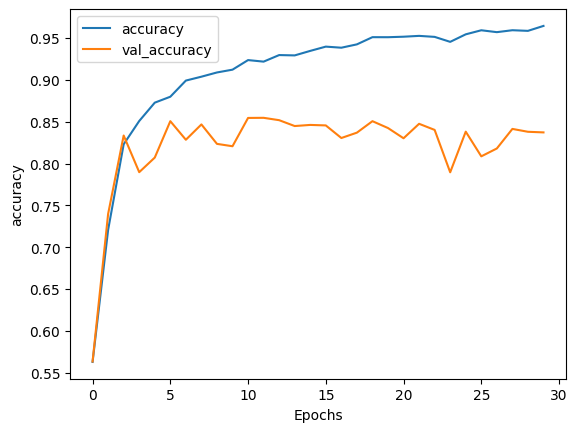

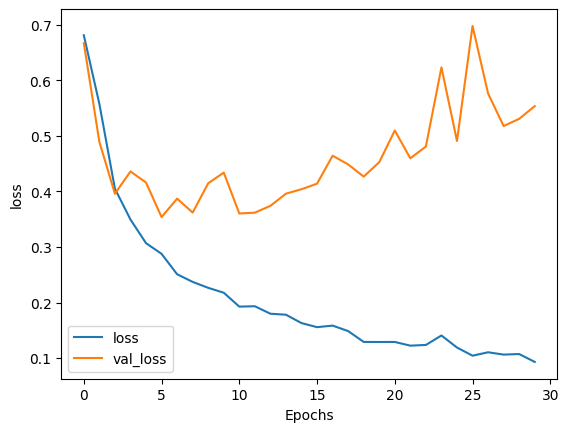

In [39]:
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")